In [17]:
import os
import pickle
import sys
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_DISPLAY_NAMES

In [18]:
project_root = '../../../..'
error_rate_level = 'typical'  # 'typical', 'high', 'stress'
overlap_criteria = 1
N_PERMUTATIONS = 1000  # increase for more precise p-values near the boundary
PERMUTATION_SEED = 42

if error_rate_level == 'typical':
    indel_rate, sub_rate = '5e-06', '0.004'
elif error_rate_level == 'high':
    indel_rate, sub_rate = '1.25e-05', '0.01'
elif error_rate_level == 'stress':
    indel_rate, sub_rate = '3.75e-05', '0.03'
else:
    raise ValueError(f'Invalid error_rate_level: {error_rate_level}')

read_lengths = [75, 100, 150, 300]

# --- Switch between benchmark comparison and ablation comparison ---
COMPARISON_MODE = 'benchmark'  # 'benchmark' or 'ablation'

BENCHMARK_MODELS = [
    'fgs_complete', 'fgs_illumina_5', 'fgs_illumina_10', 'prodigal',
    'deep_cds_no_errors',    'deep_cds_substitution',    'deep_cds_errors',
]
ABLATION_MODELS = [
    'deep_cds_a2_no_errors', 'deep_cds_a2_substitution', 'deep_cds_a2_errors',
    'deep_cds_a1_no_errors', 'deep_cds_a1_substitution', 'deep_cds_a1_errors',
    'deep_cds_no_errors',    'deep_cds_substitution',    'deep_cds_errors',
]

if COMPARISON_MODE == 'benchmark':
    models_to_compare = BENCHMARK_MODELS
elif COMPARISON_MODE == 'ablation':
    models_to_compare = ABLATION_MODELS
else:
    raise ValueError(f'Invalid COMPARISON_MODE: {COMPARISON_MODE!r}')

# all_models is the union — used only by the data-loading cell.
all_models = list(dict.fromkeys(BENCHMARK_MODELS + ABLATION_MODELS))

TT4_FAMILIES = ['Mycoplasmataceae']

LOAD_PROCESSED_DATA = True
_cache_dir = (
    f'{project_root}/data/processed_data/report_results/with_errors'
    f'/statistical_significance_testing/{indel_rate}i_{sub_rate}s'
)
# Cache filename encodes the full model set; rename if models change to avoid stale loads.
_cache_file = os.path.join(_cache_dir, 'per_read_counts_all_ablations.pkl')

In [19]:
all_test_accessions = open(
    f'{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt'
).read().splitlines()

genome_info_df = pd.read_csv(
    f'{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv'
).set_index('accession')

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        tt = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {'translation_table': tt}

tt11_accessions = [acc for acc, info in all_genomes.items()
                   if info['translation_table'] == 11]
print(f'TT11 genomes (used for evaluation): {len(tt11_accessions)}')

TT11 genomes (used for evaluation): 212


In [20]:
def get_full_cds(reads_dict):
    for read in reads_dict:
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']
        indices_to_remove = []
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [i - 1 for i in cds_frag_mapping]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                start = cds_coords[min(cds_frag_mapping)][0]
                end   = cds_coords[max(cds_frag_mapping)][1]
                indices_to_remove += cds_frag_mapping
                assert start < end
                cds_coords.append([start, end, 'disrupted_rf'])
                reads_dict[read]['cds_coords'] = cds_coords
        for idx in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(idx)
    return reads_dict


def calculate_iou(coord1, coord2):
    s1, e1, rf1 = coord1
    s2, e2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    intersection = min(e1, e2) - max(s1, s2)
    if intersection <= 0:
        return 0.0
    union = max(e1, e2) - min(s1, s2)
    return intersection / union if union > 0 else 0.0


def find_matching_genes(predicted, actual, overlap_criteria):
    matched, used = [], set()
    for pi, pc in enumerate(predicted):
        best_iou, best_ai = 0.0, -1
        for ai, ac in enumerate(actual):
            if ai in used:
                continue
            iou = calculate_iou(pc, ac)
            if iou >= overlap_criteria and iou > best_iou:
                best_iou, best_ai = iou, ai
        if best_ai != -1:
            matched.append((pi, best_ai))
            used.add(best_ai)
    return matched, len(matched)


def calculate_per_read_counts(testset_dict, preds_dict, read_names, overlap_criteria):
    """Return (tp, fp, fn) counts for each read as a numpy array of shape (n_reads, 3)."""
    rows = []
    for rn in read_names:
        gt   = testset_dict.get(rn, {}).get('cds_coords', [])
        pred = preds_dict.get(rn, {}).get('cds_coords', [])
        _, tp = find_matching_genes(pred, gt, overlap_criteria)
        rows.append((tp, len(pred) - tp, len(gt) - tp))
    return np.array(rows, dtype=np.int16)


def load_testset(acc, data_type):
    base = f'{project_root}/data/processed_data/testset_processed/{data_type}/{acc}'
    with open(f'{base}/testset_dict.pkl', 'rb') as f:
        td = pickle.load(f)
    with open(f'{base}/read_names_list.pkl', 'rb') as f:
        rn = pickle.load(f)
    return rn, get_full_cds(td)


def load_preds(acc, data_type, model):
    base = f'{project_root}/data/processed_data/predictions/processed_predictions'
    paths = {
        'fgs_complete':             f'{base}/fgs_preds/{data_type}_complete/{acc}.pkl',
        'fgs_illumina_5':           f'{base}/fgs_preds/{data_type}_illumina_5/{acc}.pkl',
        'fgs_illumina_10':          f'{base}/fgs_preds/{data_type}_illumina_10/{acc}.pkl',
        'prodigal':                 f'{base}/prodigal_preds/{data_type}/{acc}/model_preds_dict.pkl',
        # DeepCDS A2 (codon-only)
        'deep_cds_a2_no_errors':    f'{base}/DeepCDS_codon_only/model_without_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{acc}/model_preds_dict.pkl',
        'deep_cds_a2_substitution': f'{base}/DeepCDS_codon_only/model_with_substitution_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{acc}/model_preds_dict.pkl',
        'deep_cds_a2_errors':       f'{base}/DeepCDS_codon_only/model_with_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{acc}/model_preds_dict.pkl',
        # DeepCDS A1 (pLM only)
        'deep_cds_a1_no_errors':    f'{base}/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{acc}/model_preds_dict.pkl',
        'deep_cds_a1_substitution': f'{base}/DeepCDS_A1/model_with_substitution_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{acc}/model_preds_dict.pkl',
        'deep_cds_a1_errors':       f'{base}/DeepCDS_A1/model_with_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{acc}/model_preds_dict.pkl',
        # DeepCDS (full model)
        'deep_cds_no_errors':       f'{base}/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{acc}/model_preds_dict.pkl',
        'deep_cds_substitution':    f'{base}/DeepCDS/model_with_substitution_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{acc}/model_preds_dict.pkl',
        'deep_cds_errors':          f'{base}/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{acc}/model_preds_dict.pkl',
    }
    with open(paths[model], 'rb') as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

In [21]:
# per_read_counts[length][accession][model] = np.array shape (n_reads, 3): columns are tp, fp, fn

if LOAD_PROCESSED_DATA and os.path.isfile(_cache_file):
    print(f'Loading from {_cache_file} ...')
    with open(_cache_file, 'rb') as f:
        per_read_counts = pickle.load(f)
    print('Done.')
else:
    per_read_counts = {length: {} for length in read_lengths}

    for length in read_lengths:
        data_type = f'with_errors_{indel_rate}i_{sub_rate}s_{length}bp'
        print(f'\nProcessing {data_type} ...')

        for acc in tqdm(tt11_accessions, desc=f'{length}bp'):
            try:
                read_names, testset = load_testset(acc, data_type)
            except Exception:
                continue

            per_read_counts[length][acc] = {}
            for model in all_models:
                try:
                    preds = load_preds(acc, data_type, model)
                    per_read_counts[length][acc][model] = calculate_per_read_counts(
                        testset, preds, read_names, overlap_criteria
                    )
                except Exception:
                    pass

    os.makedirs(_cache_dir, exist_ok=True)
    with open(_cache_file, 'wb') as f:
        pickle.dump(per_read_counts, f)
    print(f'\nSaved to {_cache_file}')

# Report total read counts per length
for length in read_lengths:
    n_accs = len(per_read_counts[length])
    sample_model = next(iter(next(iter(per_read_counts[length].values())).values()))
    n_reads_sample = sum(
        v[next(iter(v))].shape[0]
        for v in per_read_counts[length].values() if v
    )
    print(f'{length}bp: {n_accs} genomes, ~{n_reads_sample:,} total reads')

Loading from ../../../../data/processed_data/report_results/with_errors/statistical_significance_testing/5e-06i_0.004s/per_read_counts_all_ablations.pkl ...
Done.
75bp: 212 genomes, ~20,546,911 total reads
100bp: 212 genomes, ~15,374,436 total reads
150bp: 212 genomes, ~10,203,894 total reads
300bp: 212 genomes, ~5,035,601 total reads


In [22]:
def f1_from_sums(s):
    tp, fp, fn = float(s[0]), float(s[1]), float(s[2])
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    return 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0


def _f1_vec(sums):
    """Vectorized F1 for a (k, 3) array of [tp, fp, fn] column sums."""
    tp, fp, fn = sums[:, 0], sums[:, 1], sums[:, 2]
    prec = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1e-9), 0.0)
    rec  = np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1e-9), 0.0)
    return np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-9), 0.0)


def permutation_f1_pvalue(counts_a, counts_b, n_permutations, rng):
    """Paired permutation test for equality of aggregate F1 scores.

    For each permutation, every active read independently has its model A and
    model B TP/FP/FN counts swapped with probability 0.5. Reads where both
    models have all-zero counts are excluded — they cannot affect the test
    statistic regardless of swap assignment.

    Speed: instead of a Python loop, permutations are batched as a matrix
    multiply S @ diff where S is a (chunk, n_active) float32 swap matrix and
    diff = cb - ca is (n_active, 3). This is a single BLAS SGEMM call per
    chunk and runs orders of magnitude faster than the naive loop.

    Args:
        counts_a: (n_reads, 3) int array [tp, fp, fn] for model A.
        counts_b: (n_reads, 3) int array [tp, fp, fn] for model B, same order.
        n_permutations: number of permutation iterations.
        rng: numpy random Generator.

    Returns:
        (f1_a, f1_b, observed_diff, p_value)
    """
    # Drop reads where both models contribute nothing.
    active = (counts_a.sum(axis=1) > 0) | (counts_b.sum(axis=1) > 0)
    ca = counts_a[active].astype(np.float32)
    cb = counts_b[active].astype(np.float32)
    n = len(ca)

    ca_sum = ca.sum(axis=0)   # (3,)
    cb_sum = cb.sum(axis=0)   # (3,)
    diff = cb - ca             # (n, 3), precomputed once

    f1_a = f1_from_sums(ca_sum)
    f1_b = f1_from_sums(cb_sum)
    obs_diff = f1_a - f1_b

    # Chunk size: target ~2M float32 elements per chunk to balance memory and speed.
    chunk_size = max(5, min(200, 2_000_000 // max(n, 1)))

    perm_diffs = np.empty(n_permutations)
    pos = 0
    while pos < n_permutations:
        k = min(chunk_size, n_permutations - pos)
        # S[i, j] = 1 means read j is swapped in permutation i.
        # perm_a_sums = ca_sum + S @ diff  (each row of S selects which reads flip)
        # perm_b_sums = cb_sum - S @ diff  (complement)
        S = rng.integers(0, 2, (k, n), dtype=np.uint8).astype(np.float32)
        Sd = S @ diff                                          # (k, 3) — BLAS SGEMM
        perm_diffs[pos:pos+k] = _f1_vec(ca_sum + Sd) - _f1_vec(cb_sum - Sd)
        pos += k

    # Two-tailed p-value: null distribution is symmetric around 0.
    p = float(np.mean(np.abs(perm_diffs) >= abs(obs_diff)))
    return f1_a, f1_b, obs_diff, max(p, 1.0 / n_permutations)


def run_permutation_pairwise(counts_by_acc, models, n_permutations, seed):
    """Run pairwise permutation F1 tests for all model pairs with Holm correction."""
    n = len(models)
    pairs = list(combinations(range(n), 2))
    rng = np.random.default_rng(seed)

    raw_ps, valid_pairs = [], []
    f1_cache = {}

    for i, j in tqdm(pairs, desc='pairs'):
        m_a, m_b = models[i], models[j]

        shared = [acc for acc in counts_by_acc
                  if m_a in counts_by_acc[acc] and m_b in counts_by_acc[acc]]
        if len(shared) < 5:
            continue

        ca = np.concatenate([counts_by_acc[acc][m_a] for acc in shared])
        cb = np.concatenate([counts_by_acc[acc][m_b] for acc in shared])

        f1_a, f1_b, _, p = permutation_f1_pvalue(ca, cb, n_permutations, rng)
        f1_cache[m_a] = f1_a
        f1_cache[m_b] = f1_b
        raw_ps.append(p)
        valid_pairs.append((i, j))

    p_holm = np.full((n, n), np.nan)
    if raw_ps:
        _, corrected, _, _ = multipletests(raw_ps, method='holm')
        for (i, j), p in zip(valid_pairs, corrected):
            p_holm[i, j] = p_holm[j, i] = p

    f1_obs = np.array([f1_cache.get(m, np.nan) for m in models])
    return p_holm, f1_obs


permutation_results = {}
for length in read_lengths:
    print(f'\n=== {length}bp ===')
    models = [m for m in models_to_compare if any(m in per_read_counts[length][acc]
                                                   for acc in per_read_counts[length])]
    p_mat, f1_obs = run_permutation_pairwise(
        per_read_counts[length], models, N_PERMUTATIONS, PERMUTATION_SEED
    )
    permutation_results[length] = {'models': models, 'p_matrix': p_mat, 'f1_obs': f1_obs}
    print('Observed F1 scores:')
    for m, f in zip(models, f1_obs):
        print(f'  {MODEL_DISPLAY_NAMES.get(m, m)}: {f:.4f}')


=== 75bp ===


pairs:   0%|          | 0/21 [00:00<?, ?it/s]/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_65058/535830753.py:63: RuntimeWarning: divide by zero encountered in matmul
  Sd = S @ diff                                          # (k, 3) — BLAS SGEMM
/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_65058/535830753.py:63: RuntimeWarning: overflow encountered in matmul
  Sd = S @ diff                                          # (k, 3) — BLAS SGEMM
/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_65058/535830753.py:63: RuntimeWarning: invalid value encountered in matmul
  Sd = S @ diff                                          # (k, 3) — BLAS SGEMM
pairs: 100%|██████████| 21/21 [06:41<00:00, 19.13s/it]


Observed F1 scores:
  FGS (Complete): 0.8035
  FGS (0.5% error rate): 0.7963
  FGS (1.0% error rate): 0.7914
  MetaProdigal: 0.8101
  DeepCDS: 0.8663
  DeepCDS S: 0.8732
  DeepCDS S+I: 0.8543

=== 100bp ===


pairs: 100%|██████████| 21/21 [04:53<00:00, 13.96s/it]


Observed F1 scores:
  FGS (Complete): 0.8280
  FGS (0.5% error rate): 0.8153
  FGS (1.0% error rate): 0.8085
  MetaProdigal: 0.8415
  DeepCDS: 0.9057
  DeepCDS S: 0.9130
  DeepCDS S+I: 0.8984

=== 150bp ===


pairs: 100%|██████████| 21/21 [03:09<00:00,  9.03s/it]


Observed F1 scores:
  FGS (Complete): 0.8419
  FGS (0.5% error rate): 0.8184
  FGS (1.0% error rate): 0.8089
  MetaProdigal: 0.8682
  DeepCDS: 0.9318
  DeepCDS S: 0.9421
  DeepCDS S+I: 0.9353

=== 300bp ===


pairs: 100%|██████████| 21/21 [01:33<00:00,  4.47s/it]

Observed F1 scores:
  FGS (Complete): 0.8097
  FGS (0.5% error rate): 0.7652
  FGS (1.0% error rate): 0.7521
  MetaProdigal: 0.8673
  DeepCDS: 0.9226
  DeepCDS S: 0.9436
  DeepCDS S+I: 0.9385


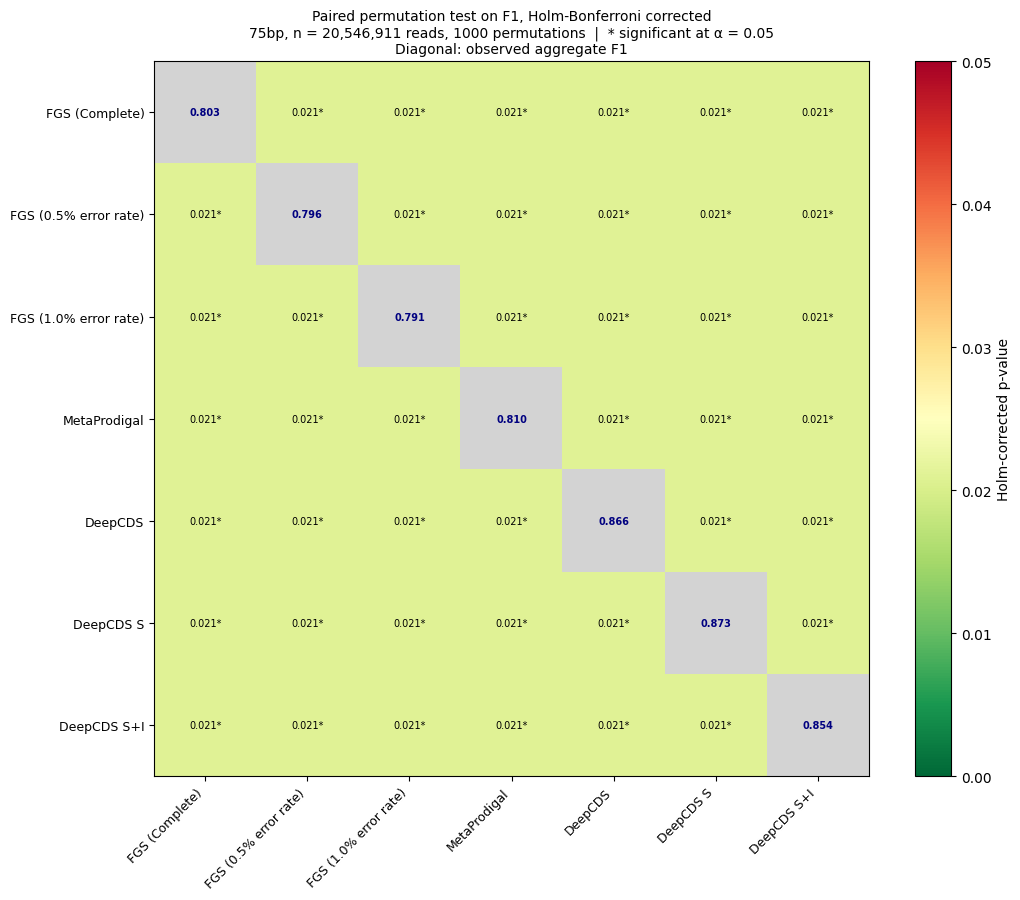

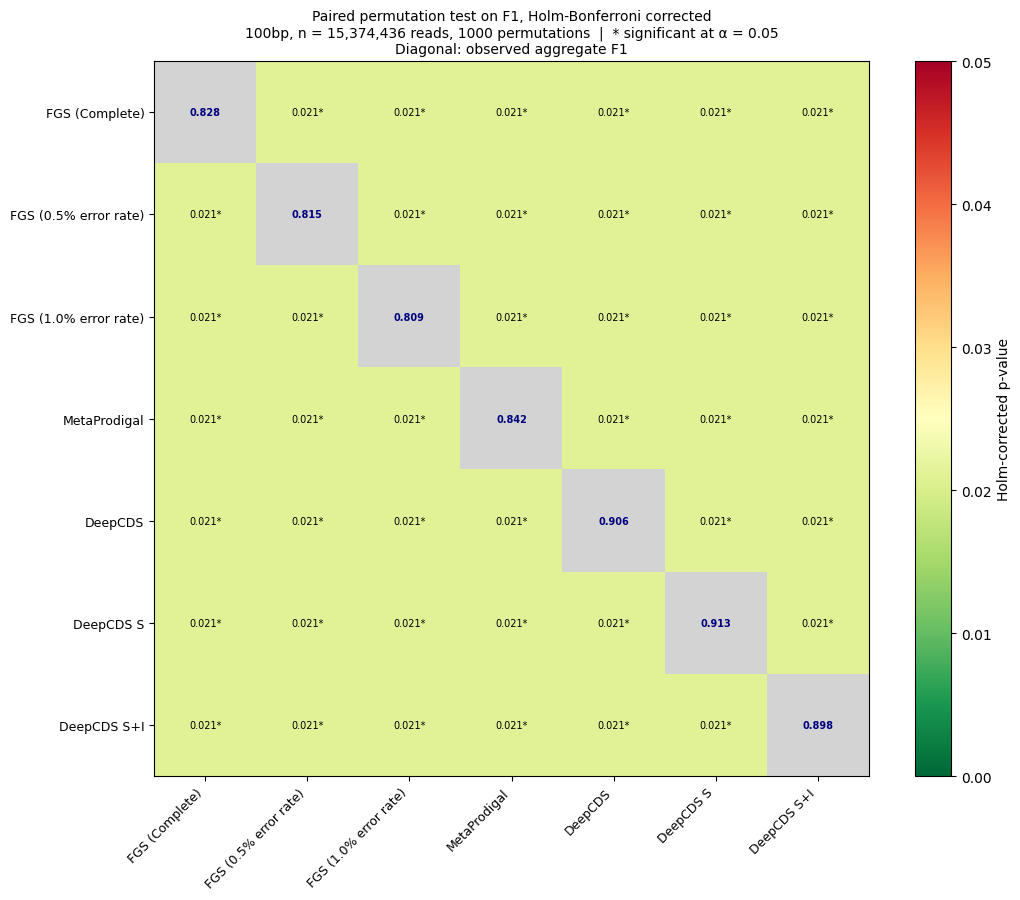

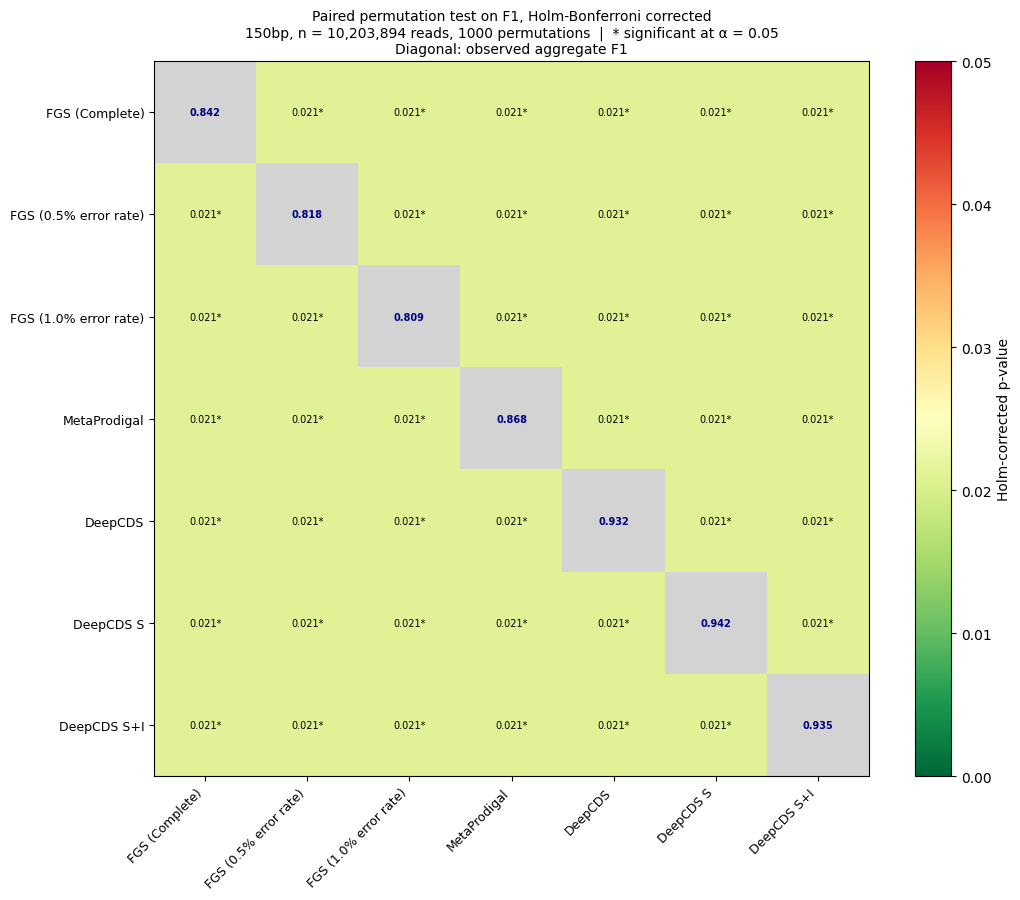

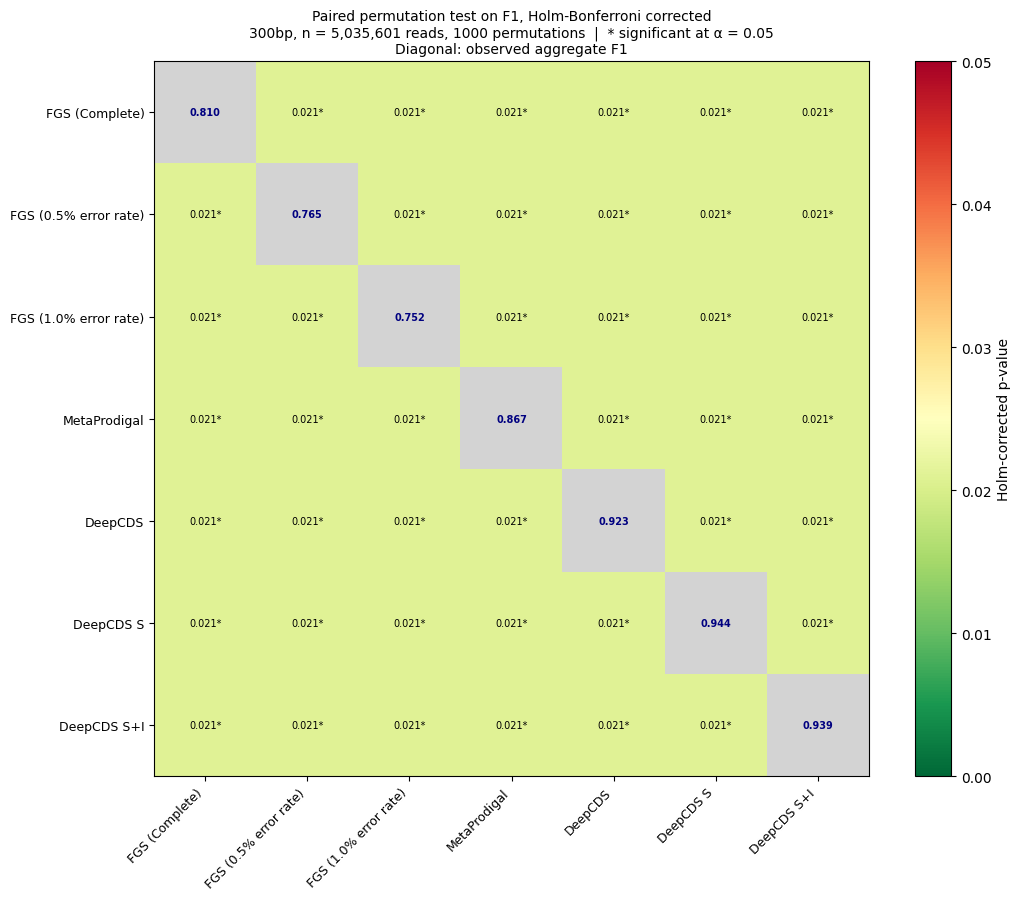

In [23]:
def plot_p_heatmap(p_matrix, models, f1_obs, length, n_reads, alpha=0.05):
    display = [MODEL_DISPLAY_NAMES.get(m, m) for m in models]
    n = len(models)

    fig, ax = plt.subplots(figsize=(11, 9))
    cmap = matplotlib.cm.RdYlGn_r.copy()
    cmap.set_bad('lightgray')

    im = ax.imshow(np.ma.masked_invalid(p_matrix), cmap=cmap, vmin=0, vmax=alpha)

    for i in range(n):
        for j in range(n):
            if i == j or np.isnan(p_matrix[i, j]):
                continue
            p = p_matrix[i, j]
            label = (f'<{1.0/N_PERMUTATIONS:.3f}' if p <= 1.0/N_PERMUTATIONS
                     else f'{p:.3f}') + ('*' if p < alpha else '')
            ax.text(j, i, label, ha='center', va='center', fontsize=7)

    for i in range(n):
        if not np.isnan(f1_obs[i]):
            ax.text(i, i, f'{f1_obs[i]:.3f}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='navy')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(display, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(display, fontsize=9)
    plt.colorbar(im, ax=ax, label='Holm-corrected p-value')
    ax.set_title(
        f'Paired permutation test on F1, Holm-Bonferroni corrected\n'
        f'{length}bp, n = {n_reads:,} reads, {N_PERMUTATIONS} permutations'
        f'  |  * significant at α = {alpha}\n'
        f'Diagonal: observed aggregate F1',
        fontsize=10
    )
    plt.tight_layout()
    # plt.savefig(f'permutation_f1_heatmap_{length}bp.svg', dpi=300)
    plt.show()


for length in read_lengths:
    res = permutation_results[length]
    n_reads = sum(
        per_read_counts[length][acc][res['models'][0]].shape[0]
        for acc in per_read_counts[length]
        if res['models'][0] in per_read_counts[length][acc]
    )
    plot_p_heatmap(
        res['p_matrix'], res['models'], res['f1_obs'],
        length, n_reads
    )

In [24]:
BENCHMARK_KEY_PAIRS = [
    ('deep_cds_substitution', 'fgs_complete'),
    ('deep_cds_substitution', 'fgs_illumina_5'),
    ('deep_cds_substitution', 'fgs_illumina_10'),
    ('deep_cds_substitution', 'prodigal'),
    ('deep_cds_errors',       'fgs_complete'),
    ('deep_cds_errors',       'fgs_illumina_5'),
    ('deep_cds_errors',       'fgs_illumina_10'),
    ('deep_cds_errors',       'prodigal'),
]

ABLATION_KEY_PAIRS = [
    # Architecture comparisons (matching training condition)
    ('deep_cds_errors',          'deep_cds_a1_errors'),
    ('deep_cds_errors',          'deep_cds_a2_errors'),
    ('deep_cds_a1_errors',       'deep_cds_a2_errors'),
    ('deep_cds_substitution',    'deep_cds_a1_substitution'),
    ('deep_cds_substitution',    'deep_cds_a2_substitution'),
    ('deep_cds_a1_substitution', 'deep_cds_a2_substitution'),
]

key_pairs = BENCHMARK_KEY_PAIRS if COMPARISON_MODE == 'benchmark' else ABLATION_KEY_PAIRS

rows = []
for m1, m2 in key_pairs:
    row = {
        'Model A': MODEL_DISPLAY_NAMES.get(m1, m1),
        'Model B': MODEL_DISPLAY_NAMES.get(m2, m2),
    }
    for length in read_lengths:
        res = permutation_results[length]
        models = res['models']
        if m1 in models and m2 in models:
            i, j = models.index(m1), models.index(m2)
            p = res['p_matrix'][i, j]
            if np.isnan(p):
                row[f'{length}bp'] = 'N/A'
            elif p <= 1.0 / N_PERMUTATIONS:
                row[f'{length}bp'] = f'<{1.0/N_PERMUTATIONS:.3f}'
            else:
                row[f'{length}bp'] = f'{p:.3f}'
        else:
            row[f'{length}bp'] = 'N/A'
    rows.append(row)

summary = pd.DataFrame(rows)
print(f'Holm-corrected permutation p-values ({N_PERMUTATIONS} permutations) [{COMPARISON_MODE}]')
print(summary.to_string(index=False))

Holm-corrected permutation p-values (1000 permutations) [benchmark]
    Model A               Model B  75bp 100bp 150bp 300bp
  DeepCDS S        FGS (Complete) 0.021 0.021 0.021 0.021
  DeepCDS S FGS (0.5% error rate) 0.021 0.021 0.021 0.021
  DeepCDS S FGS (1.0% error rate) 0.021 0.021 0.021 0.021
  DeepCDS S          MetaProdigal 0.021 0.021 0.021 0.021
DeepCDS S+I        FGS (Complete) 0.021 0.021 0.021 0.021
DeepCDS S+I FGS (0.5% error rate) 0.021 0.021 0.021 0.021
DeepCDS S+I FGS (1.0% error rate) 0.021 0.021 0.021 0.021
DeepCDS S+I          MetaProdigal 0.021 0.021 0.021 0.021
